
1) Imports & Settings




In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve,precision_score,recall_score,f1_score,accuracy_score


## 2) Load Dataset
**Academic & Behavioral Features:**
| Feature              | Description                            |
| -------------------- | -------------------------------------- |
| `hours_study`        | Average number of study hours per week |
| `attendance_rate`    | Class attendance percentage            |
| `gpa_prev`           | Previous academic GPA (0–4 scale)      |
| `extra_activities`   | Number of extracurricular activities   |
| `sleep_hours`        | Average sleep hours per night          |
| `social_media_hours` | Daily hours spent on social media      |

**Demographic Features:**
| Feature  | Description                  |
| -------- | ---------------------------- |
| `gender` | Student gender (categorical) |
| `city`   | Student’s city of residence  |



In [139]:
DATA_PATH="Student Performance Dataset.csv"

RANDOM_STATE= 1

TEST_SIZE=0.2



In [140]:
df=pd.read_csv(DATA_PATH)
df.head()

,hours_study,attendance_rate,gpa_prev,extra_activities,sleep_hours,social_media_hours,gender,city,passed
0,20.0,88.6,2.58,4,7.5,2.8,Male,Cairo,1
1,21.8,88.9,NaN,2,7.5,2.7,Female,Alexandria,1
2,18.4,80.8,2.70,3,6.0,2.4,Male,Giza,1
3,14.7,100.0,2.27,1,6.3,3.7,Female,Alexandria,1
4,17.3,88.7,3.27,0,4.5,0.0,Male,Cairo,1


## 3) Quick Dataset Check


We check:
- shape
- column types
- missing values
- target distribution


In [141]:
print(f'the shape of data is :{df.shape}')

the shape of data is :(1020, 9)


In [142]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   hours_study         971 non-null    float64
 1   attendance_rate     969 non-null    float64
 2   gpa_prev            968 non-null    float64
 3   extra_activities    1020 non-null   int64  
 4   sleep_hours         1020 non-null   float64
 5   social_media_hours  970 non-null    float64
 6   gender              1020 non-null   object 
 7   city                1020 non-null   object 
 8   passed              1020 non-null   int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 71.8+ KB


In [143]:
missing_value=df.isnull().sum()
missing_value_per= df.isnull().mean()*100
missing_df=pd.DataFrame({
    "missing_value":missing_value,
    "missing_value_per":missing_value_per
})
missing_df.sort_values(by="missing_value_per",ascending=False)

,missing_value,missing_value_per
gpa_prev,52,5.098039
attendance_rate,51,5.000000
social_media_hours,50,4.901961
hours_study,49,4.803922
extra_activities,0,0.000000
sleep_hours,0,0.000000
gender,0,0.000000
city,0,0.000000
passed,0,0.000000


In [144]:
df['passed'].value_counts()   #over_sampling

,count
passed,
1,946
0,74


In [145]:
df['passed'].value_counts(normalize=True)

,proportion
passed,
1,0.927451
0,0.072549


## 4) Lightweight EDA (Safe)
EDA is **not leakage** by itself, but avoid decisions that *use test information*.
Here we do simple plots to understand ranges and imbalance.


In [146]:
numeric_col=df.select_dtypes(include="number").columns.tolist()[:-1]
numeric_col

['hours_study',
 'attendance_rate',
 'gpa_prev',
 'extra_activities',
 'sleep_hours',
 'social_media_hours']

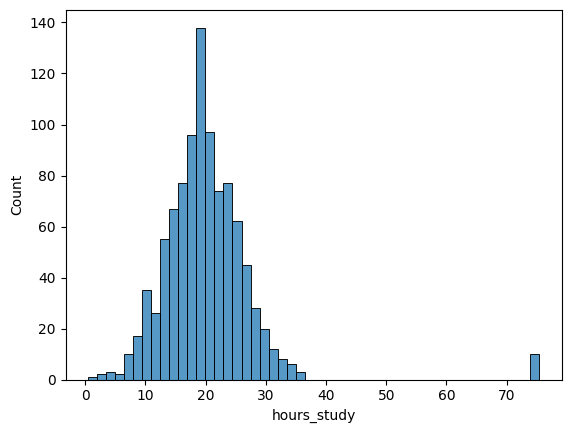

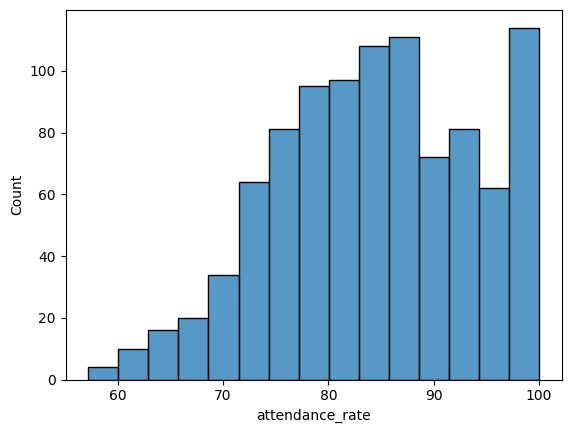

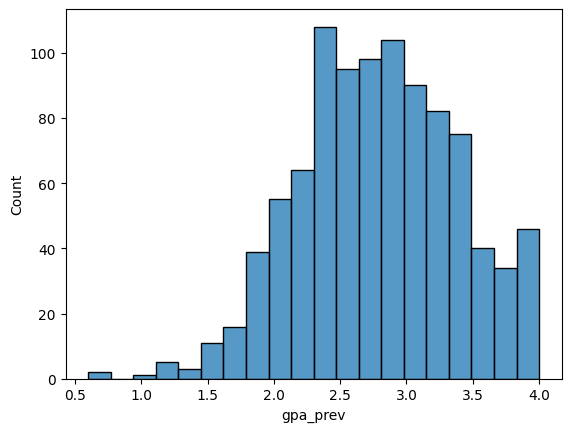

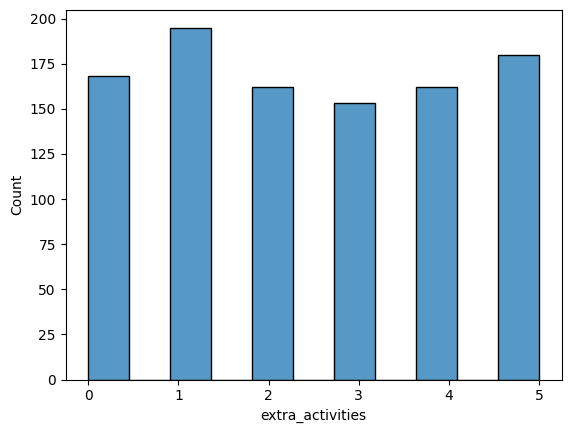

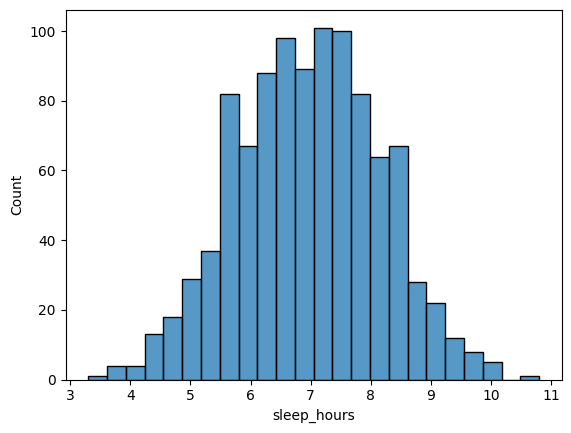

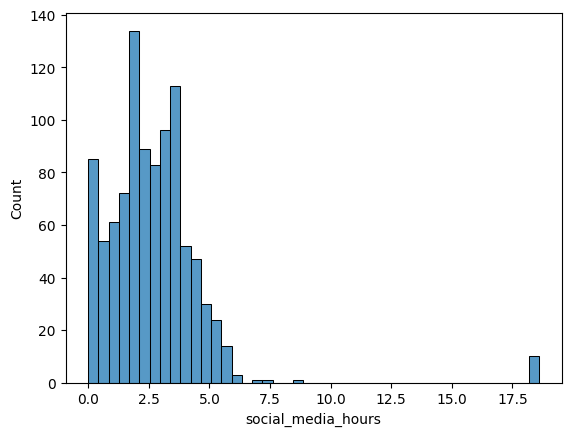

In [147]:
for col in numeric_col:
  sns.histplot(df,x=col)
  plt.show()

In [148]:
categoric_col=df.select_dtypes(include="object").columns.tolist()
categoric_col

['gender', 'city']

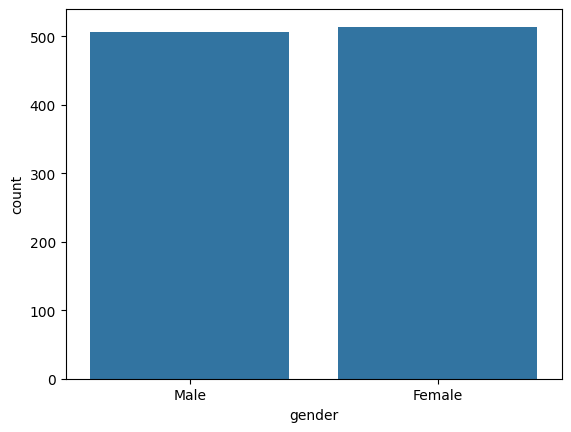

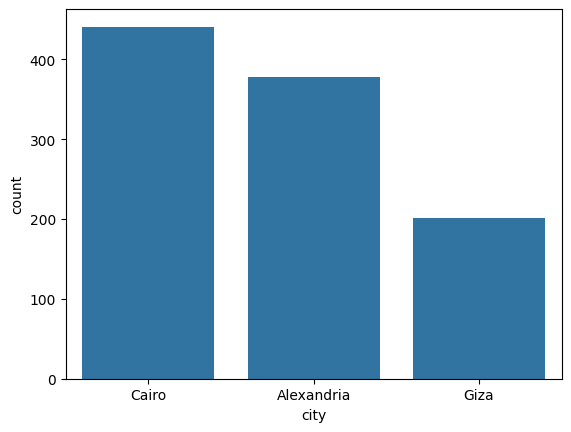

In [149]:
for col in categoric_col:
  sns.countplot(df,x=col)
  plt.show()

## 5) Define Features (X) and Target (y)
We keep the raw dataframe intact. **No imputation, scaling, or encoding yet**.


In [150]:
x=df.drop(columns="passed")
y=df["passed"]

## 6) Train/Test Split (FIRST)
This is the most important step for leakage prevention.
We also use `stratify=y` to keep class proportions consistent.


In [151]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=TEST_SIZE,random_state=RANDOM_STATE,stratify=y)

**7) Outliers** (Leakage-Safe Detection + Treatment with datasist)
Outliers can skew:

distance-based steps (like KNNImputer),
scaling,
and model coefficients (especially if a few extreme values dominate).

In [152]:
def find_outlier(df,features):
  outliers=[]
  for col in features:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr
    outliers_col=df[(df[col]<lower_bound)|(df[col]>upper_bound)]
    outliers.append(outliers_col)
  return pd.concat(outliers)
outlier_indices=find_outlier(x_train,numeric_col).index
print(f'number of outliers: {len(outlier_indices)}')
print(f'the shape of x_train before outlier treatment: {x_train.shape}')
print(f'the shape of y_train before outlier treatment: {y_train.shape}')
x_train = x_train.drop(outlier_indices, axis=0)
y_train = y_train.drop(outlier_indices, axis=0)
print(f'the shape of x_train after outlier treatment: {(x_train).shape}')
print(f'the shape of y_train after outlier treatment: {(y_train).shape}')


number of outliers: 31
the shape of x_train before outlier treatment: (816, 8)
the shape of y_train before outlier treatment: (816,)
the shape of x_train after outlier treatment: (785, 8)
the shape of y_train after outlier treatment: (785,)


8) Preprocessing Pipeline (fit on TRAIN only)

Numeric features
KNN Imputer ,
Scaling (StandardScaler)

Categorical features
Missing values → most frequent value ,
One-hot encoding (categories learned from training)


In [153]:
numeric_transform=Pipeline(
    steps=[
        ("impute",KNNImputer(n_neighbors = 5)),
        ("scaler",StandardScaler())
    ]
)
categorical_transform=Pipeline(
    steps=[
        ("impute",SimpleImputer(strategy="most_frequent")),
        ("ohe",OneHotEncoder(handle_unknown="ignore",drop="first"))
    ])

In [154]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num",numeric_transform,numeric_col),
        ("cat",categorical_transform,categoric_col)
    ]
)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute', KNNImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['hours_study', 'attendance_rate', 'gpa_prev',
                                  'extra_activities', 'sleep_hours',
                                  'social_media_hours']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['gender', 'city'])])

## 9) Model Pipeline + SMOTE (Training only)

**Correct order inside training:**
1) Preprocess  
2) SMOTE (only on the already-preprocessed training data)  
3) Logistic Regression  

We use `imblearn.pipeline.Pipeline` so SMOTE is applied during `.fit()` but not during `.predict()`/`.predict_proba()`.

In [155]:
model=ImbPipeline(
    steps=[
        ("preprocesor",preprocessor),
        ("smote",SMOTE(random_state=RANDOM_STATE,k_neighbors = 5)),
        ("classifer",LogisticRegression(random_state=RANDOM_STATE))
    ]
)
model

Pipeline(steps=[('preprocesor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['hours_study',
                                                   'attendance_rate',
                                                   'gpa_prev',
                                                   'extra_activities',
                                                   'sleep_hours',
                                                   'social_media_hours']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'city'])])),
                ('smote', SMOTE(random_state=1)),
                ('classifer', LogisticRegression(random_state=1))])

10) Train

In [156]:
model.fit(x_train,y_train)

Pipeline(steps=[('preprocesor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['hours_study',
                                                   'attendance_rate',
                                                   'gpa_prev',
                                                   'extra_activities',
                                                   'sleep_hours',
                                                   'social_media_hours']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'city'])])),
                ('smote', SMOTE(random_state=1)),
                ('classifer', LogisticRegression(random_state=1))])

11) Evaluate on Test Set (No leakage)
We evaluate using:

Confusion Matrix
Accuracy_Score, Pression_Score, Recall_Score
ROC-AUC (using probabilities)

In [157]:
y_pred=model.predict(x_test)


In [158]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[ 11,   4],
       [ 50, 139]])

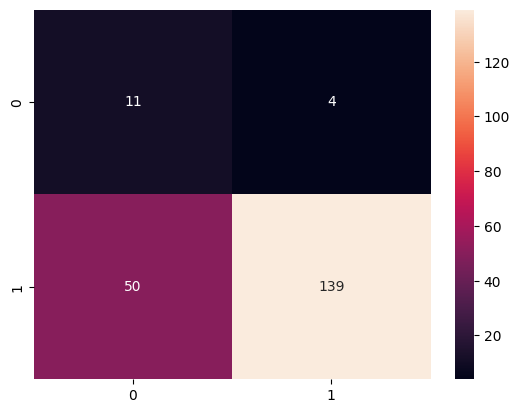

In [159]:
sns.heatmap(cm,annot=True,fmt="d")
plt.show()

In [160]:
accuracy_score=accuracy_score(y_test,y_pred)
precision_score=precision_score(y_test,y_pred)
recall_score=recall_score(y_test,y_pred)
f1_score=f1_score(y_test,y_pred)
print(f'accuracy_score: {accuracy_score}')
print(f'precision_score: {precision_score}')
print(f'recall_score: {recall_score}')
print(f'f1_score: {f1_score}')
#

accuracy_score: 0.7352941176470589
precision_score: 0.972027972027972
recall_score: 0.7354497354497355
f1_score: 0.8373493975903614


## 12) ROC Curve

In [161]:
y_pred_proba=model.predict_proba(x_test)[:,1]
y_pred_proba[:10]

array([0.74888969, 0.79835746, 0.5141938 , 0.93155072, 0.94998527,
       0.97269723, 0.3463087 , 0.98351476, 0.92234791, 0.8403141 ])

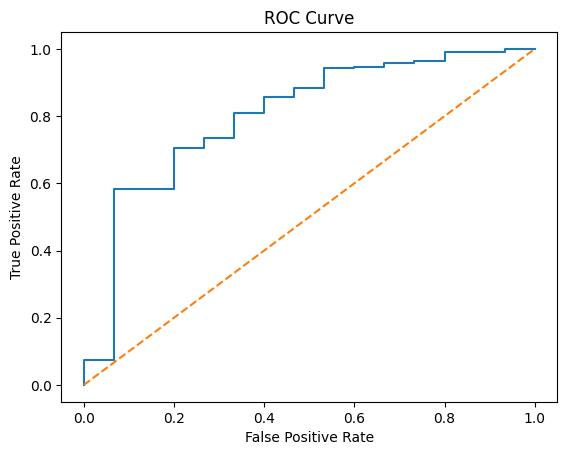

In [162]:
fbr,tbr,_=roc_curve(y_test,y_pred_proba)
plt.plot(fbr,tbr)
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [163]:
auc=roc_auc_score(y_test,y_pred_proba)
print(f'the area under the cure:{auc}')

the area under the cure:0.801058201058201


13) Interpret Coefficients (+/− meaning)

Interpretation:

Positive coefficient → increases log-odds → increases probability of class 1 (passed)

Negative coefficient → decreases log-odds → decreases probability of class 1



In [164]:
model

Pipeline(steps=[('preprocesor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['hours_study',
                                                   'attendance_rate',
                                                   'gpa_prev',
                                                   'extra_activities',
                                                   'sleep_hours',
                                                   'social_media_hours']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'city'])])),
                ('smote', SMOTE(random_state=1)),
                ('classifer', LogisticRegression(random_state=1))])

In [165]:
clf=model.named_steps["classifer"]
ohe=model.named_steps["preprocesor"].named_transformers_["cat"].named_steps['ohe']


In [166]:
cat_name=ohe.get_feature_names_out()
cat_name

array(['x0_Male', 'x1_Cairo', 'x1_Giza'], dtype=object)

In [167]:
numeric_col

['hours_study',
 'attendance_rate',
 'gpa_prev',
 'extra_activities',
 'sleep_hours',
 'social_media_hours']

In [168]:
features_name= numeric_col + cat_name.tolist()
features_name

['hours_study',
 'attendance_rate',
 'gpa_prev',
 'extra_activities',
 'sleep_hours',
 'social_media_hours',
 'x0_Male',
 'x1_Cairo',
 'x1_Giza']

In [169]:
coefs=clf.coef_.ravel()
coefs

array([ 0.85129731,  0.75720572,  1.13733987, -0.01865637, -0.00243074,
       -0.2775965 ,  0.11628264,  0.69828968,  0.13510177])

In [170]:
important_df=pd.DataFrame({
    "features":features_name,
    "coef":coefs,
    'Odds_Ratio': np.exp(coefs)
    }).sort_values(by='coef', ascending=False)
important_df

,features,coef,Odds_Ratio
2,gpa_prev,1.137340,3.118462
0,hours_study,0.851297,2.342684
1,attendance_rate,0.757206,2.132310
7,x1_Cairo,0.698290,2.010311
8,x1_Giza,0.135102,1.144653
6,x0_Male,0.116283,1.123313
4,sleep_hours,-0.002431,0.997572
3,extra_activities,-0.018656,0.981517
5,social_media_hours,-0.277597,0.757602
